In [1]:
from datetime import datetime

print(f"Timestamp: {datetime.now()}")

Timestamp: 2025-12-10 10:51:19.786297


# Recluster neurons

KA adding this notebook to rum umap and clustering after scvi on neuron subset

**Pinned Environment:** [`envs/sc-scvi.yaml`](../.../envs/sc-scvi.yaml)  

In [1]:
from pathlib import Path
import os
import scanpy as sc
import pandas as pd
import numpy as np
import anndata as ad
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
import matplotlib.patches as mpatches
import matplotlib.colors as mcolors
import seaborn as sns
from scipy import sparse
import warnings
import session_info
import sys

In [2]:
plt.rcParams['figure.figsize'] = (3, 3)
plt.rcParams['figure.dpi'] = 150

### Setup

In [3]:
sys.path.append(str(Path.cwd().resolve().parents[1]))

from config.paths import BASE_DIR

input_dir = BASE_DIR / "data/h5ad/export_04/04a_neurons"
adata_filt_path = input_dir / "neuron_filt_adata.h5ad"
adata_unfilt_path = input_dir / "neuron_unfilt_adata.h5ad"

output_dir = BASE_DIR / "data/h5ad/export_04/04b_reclustered"
output_dir.mkdir(parents=True, exist_ok=True)

In [4]:
adata_filt = sc.read_h5ad(adata_filt_path)
adata_unfilt = sc.read_h5ad(adata_unfilt_path)

In [5]:
print(adata_filt)
print("-"*40)
print(adata_unfilt)

AnnData object with n_obs × n_vars = 10276 × 475
    obs: 'cell_id', 'x_centroid', 'y_centroid', 'transcript_counts', 'control_probe_counts', 'genomic_control_counts', 'control_codeword_counts', 'unassigned_codeword_counts', 'deprecated_codeword_counts', 'total_counts', 'cell_area', 'nucleus_area', 'nucleus_count', 'segmentation_method', 'sample_id', 'output_id', 'region_id', 'slide_id', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'log1p_total_counts', 'pct_counts_in_top_10_genes', 'pct_counts_in_top_20_genes', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_150_genes', 'batch', '_scvi_batch', '_scvi_labels', 'predicted.id', 'prediction.score.CGRP.Theta', 'prediction.score.CGRP.Gamma', 'prediction.score.CGRP.Alpha', 'prediction.score.Nonpeptidergic.nociceptors', 'prediction.score.C.LTMR', 'prediction.score.Sst', 'prediction.score.CGRP.Zeta', 'prediction.score.CGRP.Epsilion', 'prediction.score.Proprioceptors', 'prediction.score.Unknown', 'prediction.score.Adelta.LTMR', 'prediction.

# Neighbors graph

In [6]:
# first run through on unfiltered dataset
sc.pp.neighbors(adata_unfilt, use_rep = 'X_scVI_neuron_unfilt', random_state = 0)
sc.tl.umap(adata_unfilt, random_state = 0)
sc.tl.leiden(adata_unfilt, key_added='neuron_recluster', resolution=0.25)

/home/workspace/environment/sc-scvi/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/tmp/ipykernel_7936/2162809992.py:4: FutureWarning: In the future, the default backend for leiden will be igraph instead of leidenalg.

 To achieve the future defaults please pass: flavor="igraph" and n_iterations=2.  directed must also be False to work with igraph's implementation.
  sc.tl.leiden(adata_unfilt, key_added='neuron_recluster', resolution=0.25)


In [7]:
# then run through on filtered dataset
print('neighbors')
sc.pp.neighbors(adata_filt, use_rep = 'X_scVI_neuron_filt', random_state = 0)
print('umap')
sc.tl.umap(adata_filt, random_state = 0)
print('leiden')
sc.tl.leiden(adata_filt, key_added='neuron_recluster', resolution=0.25)

neighbors
umap
leiden


In [10]:
def assign_cell_type_colors(adata, key="cell_type"):
    """
    Assigns a tab10 color palette to a categorical obs field.
    If there are more than 10 categories, the palette cycles.
    """
    # Ensure categorical
    adata.obs[key] = adata.obs[key].astype("category")
    
    cats = adata.obs[key].cat.categories
    n = len(cats)

    # tab10 gives 10 colors; using modulo lets us cycle if n > 1=20
    base_palette = sns.color_palette("tab20", 20)

    palette = [mcolors.to_hex(base_palette[i % 20]) for i in range(n)]

    # assign colors in category order
    adata.uns[f"{key}_colors"] = palette

In [20]:
adata_unfilt

AnnData object with n_obs × n_vars = 21660 × 475
    obs: 'cell_id', 'x_centroid', 'y_centroid', 'transcript_counts', 'control_probe_counts', 'genomic_control_counts', 'control_codeword_counts', 'unassigned_codeword_counts', 'deprecated_codeword_counts', 'total_counts', 'cell_area', 'nucleus_area', 'nucleus_count', 'segmentation_method', 'sample_id', 'output_id', 'region_id', 'slide_id', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'log1p_total_counts', 'pct_counts_in_top_10_genes', 'pct_counts_in_top_20_genes', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_150_genes', 'batch', '_scvi_batch', '_scvi_labels', 'predicted.id', 'prediction.score.CGRP.Theta', 'prediction.score.CGRP.Gamma', 'prediction.score.CGRP.Alpha', 'prediction.score.Nonpeptidergic.nociceptors', 'prediction.score.C.LTMR', 'prediction.score.Sst', 'prediction.score.CGRP.Zeta', 'prediction.score.CGRP.Epsilion', 'prediction.score.Proprioceptors', 'prediction.score.Unknown', 'prediction.score.Adelta.LTMR', 'prediction.

In [11]:
adata_filt

AnnData object with n_obs × n_vars = 10276 × 475
    obs: 'cell_id', 'x_centroid', 'y_centroid', 'transcript_counts', 'control_probe_counts', 'genomic_control_counts', 'control_codeword_counts', 'unassigned_codeword_counts', 'deprecated_codeword_counts', 'total_counts', 'cell_area', 'nucleus_area', 'nucleus_count', 'segmentation_method', 'sample_id', 'output_id', 'region_id', 'slide_id', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'log1p_total_counts', 'pct_counts_in_top_10_genes', 'pct_counts_in_top_20_genes', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_150_genes', 'batch', '_scvi_batch', '_scvi_labels', 'predicted.id', 'prediction.score.CGRP.Theta', 'prediction.score.CGRP.Gamma', 'prediction.score.CGRP.Alpha', 'prediction.score.Nonpeptidergic.nociceptors', 'prediction.score.C.LTMR', 'prediction.score.Sst', 'prediction.score.CGRP.Zeta', 'prediction.score.CGRP.Epsilion', 'prediction.score.Proprioceptors', 'prediction.score.Unknown', 'prediction.score.Adelta.LTMR', 'prediction.

In [18]:
assign_cell_type_colors(adata_filt,  key="cell_type")
assign_cell_type_colors(adata_unfilt,  key="cell_type")

In [14]:
del adata_filt.uns['cell_type_colors']
del adata_unfilt.uns['cell_type_colors']

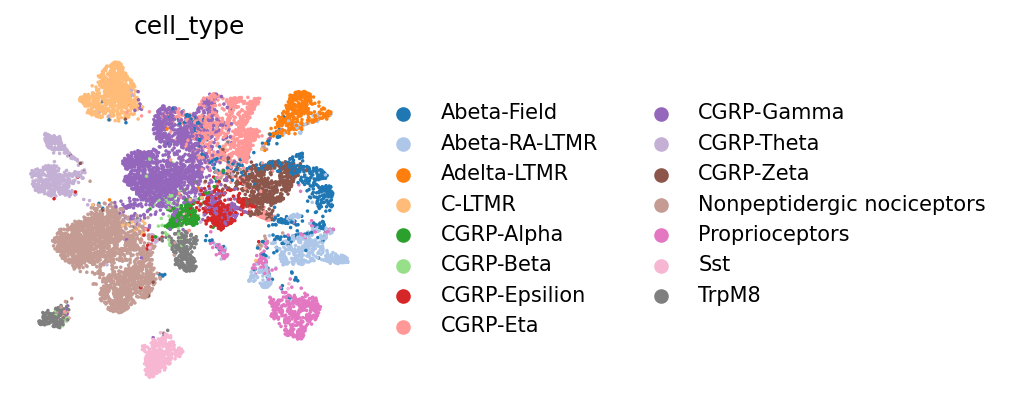

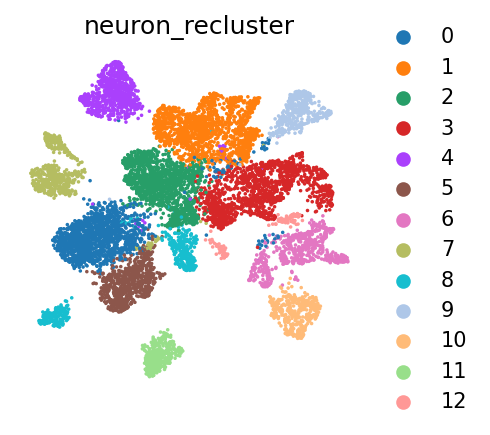

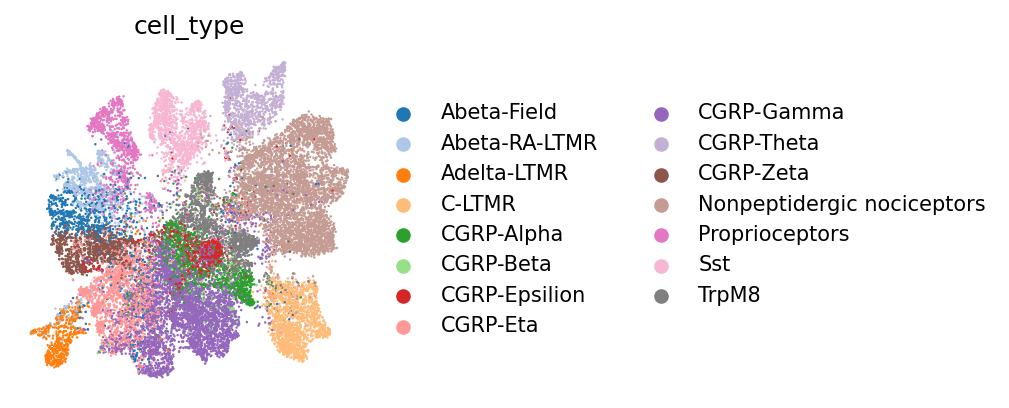

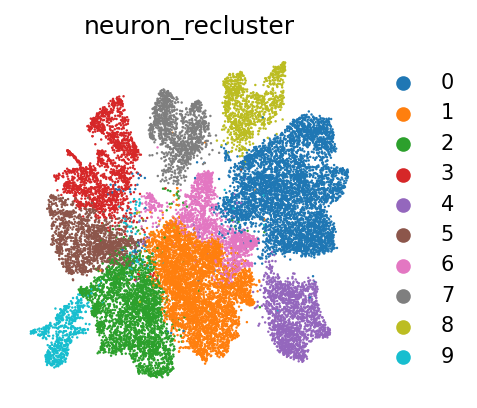

In [19]:
sc.pl.umap(adata_filt, color = 'cell_type', frameon = False)
sc.pl.umap(adata_filt, color = 'neuron_recluster', frameon = False)
sc.pl.umap(adata_unfilt, color = 'cell_type', frameon = False)
sc.pl.umap(adata_unfilt, color = 'neuron_recluster', frameon = False)


# Export

In [16]:
adata_filt_path = os.path.join(output_dir, 'neuron_filt_adata_subcluster.h5ad')
adata_unfilt_path = os.path.join(output_dir, 'neuron_unfilt_adata_subcluster.h5ad')

adata_filt.write_h5ad(adata_filt_path, compression='gzip') 
adata_unfilt.write_h5ad(adata_unfilt_path, compression='gzip')

print(adata_filt_path)
print(adata_unfilt_path)

/home/workspace/DRG/spatial_mouse_drg_outputs/yano/data/h5ad/export_04/04b_reclustered/neuron_filt_adata_subcluster.h5ad
/home/workspace/DRG/spatial_mouse_drg_outputs/yano/data/h5ad/export_04/04b_reclustered/neuron_unfilt_adata_subcluster.h5ad


## Session info

In [17]:
print('active IDE: sc-spatial-gpu')
print('active conda environment:', os.path.basename(sys.prefix))
session_info.show()

active IDE: sc-spatial-gpu
active conda environment: sc-scvi


/home/workspace/environment/sc-scvi/lib/python3.12/site-packages/session_info/main.py:213: UserWarning: The '__version__' attribute is deprecated and will be removed in MarkupSafe 3.1. Use feature detection, or `importlib.metadata.version("markupsafe")`, instead.
  mod_version = _find_version(mod.__version__)
